In [33]:
%matplotlib widget
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

### Pandas and Matplotlib

Visualization is an important tool when working with data. Luckily, Pandas provides direct support for working with Matplotlib.

In [34]:
df = pd.read_csv("grades.csv")

In [35]:
df.columns

Index(['# First name', ' Last name', ' Student number', ' Quizzes average',
       ' HW1 mark', ' HW2 mark', ' HW3 mark', ' Exam1 mark', ' Exam2 mark',
       ' Final exam mark'],
      dtype='object')

In [36]:
qz = df[' Quizzes average']
hw1 = df[' HW1 mark']
hw2 = df[' HW2 mark']
hw3 = df[' HW3 mark']

grade_bins = [0,10,20,30,40,50,60,70,80,90,100]

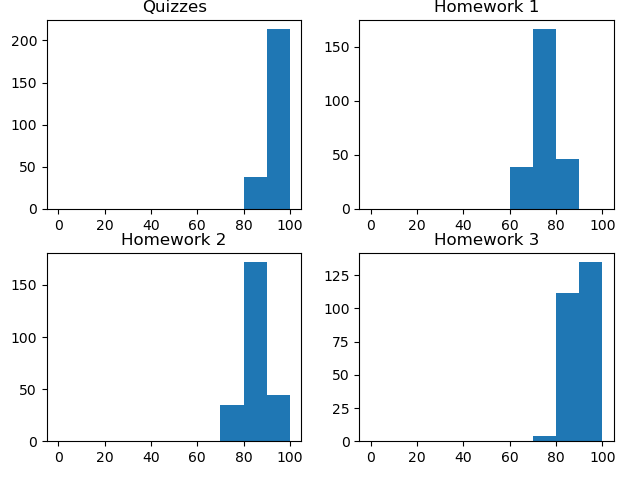

In [37]:
fig, ax = plt.subplots(2,2)
fig.tight_layout()
p1 = ax[0,0].hist(qz, bins = grade_bins, label = r'Quizzes' )
ax[0,0].set_title('Quizzes')
p2 = ax[0,1].hist(hw1, bins = grade_bins, label = r'Homework 1')
ax[0,1].set_title('Homework 1')
p3 = ax[1,0].hist(hw2, bins = grade_bins, label = r'Homework 2')
ax[1,0].set_title('Homework 2')
p4 = ax[1,1].hist(hw3, bins = grade_bins, label = r'Homework 3')
ax[1,1].set_title('Homework 3')

plt.show()

In [38]:
plt.close('all')

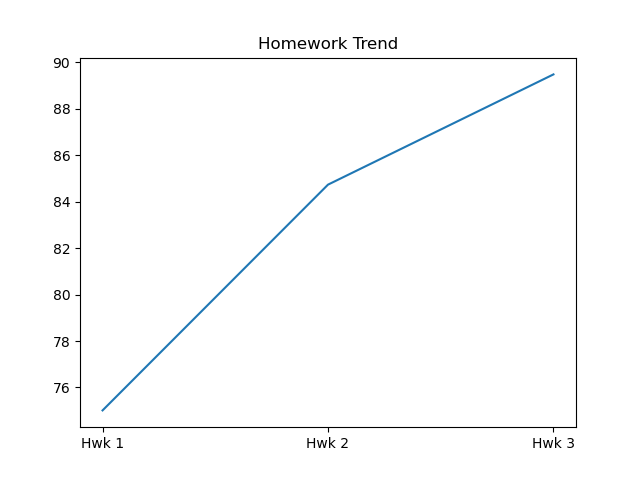

In [39]:
hwktrend = np.array([np.mean(hw1), np.mean(hw2), np.mean(hw3)])
sHwk = pd.Series(data = hwktrend, index = ["Hwk 1", "Hwk 2", "Hwk 3"])
plt.plot(sHwk)
plt.title("Homework Trend")
plt.show()

In [40]:
df = pd.read_csv("JohnBookData.csv")
df= df.loc[:, 'Title': 'Date Added']
df = df.drop(columns = ['Additional Authors', 'Author l-f', 'Binding', 'ISBN', 'ISBN13'])

In [41]:
df.head()

,Title,Author,My Rating,Average Rating,Publisher,Number of Pages,Year Published,Original Publication Year,Date Read,Date Added
0,Last Night in Montreal,Emily St. John Mandel,5,3.74,Vintage,230,2009.0,2009.0,2026/01/26,2026/01/25
1,Why Men Lie (The Cape Breton Trilogy #3),Linden MacIntyre,4,3.47,Random House Canada,384,2012.0,2012.0,2026/01/20,2026/01/15
2,Logicomix: An Epic Search for Truth,Apostolos Doxiadis,0,4.06,Bloomsbury (NYC),347,2009.0,2009.0,NaN,2019/02/16
3,The Man Who Loved Only Numbers: The Story of ...,Paul Hoffman,3,4.06,Grand Central Publishing,302,1998.0,1998.0,2026/01/18,2026/01/18
4,White Noise,Don DeLillo,0,3.86,Penguin Classics,320,2016.0,1985.0,NaN,2026/01/15


In [42]:
pubdate = df['Original Publication Year']
pages = df['Number of Pages']
my_rating  = df['My Rating']
rating = df['Average Rating']

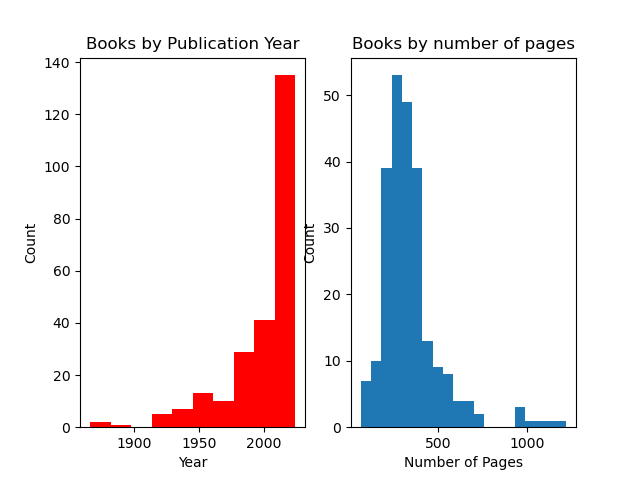

In [43]:
fig, ax = plt.subplots(1,2)

fig.tight_layout
p1 = ax[0].hist(pubdate, color = 'red')
ax[0].set_title('Books by Publication Year')
ax[0].set_xlabel('Year')
ax[0].set_ylabel('Count')
p2 = ax[1].hist(pages, bins = 20)
ax[1].set_title('Books by number of pages')
ax[1].set_xlabel('Number of Pages')
ax[1].set_ylabel('Count')
plt.show()


In [54]:
plt.close('all')

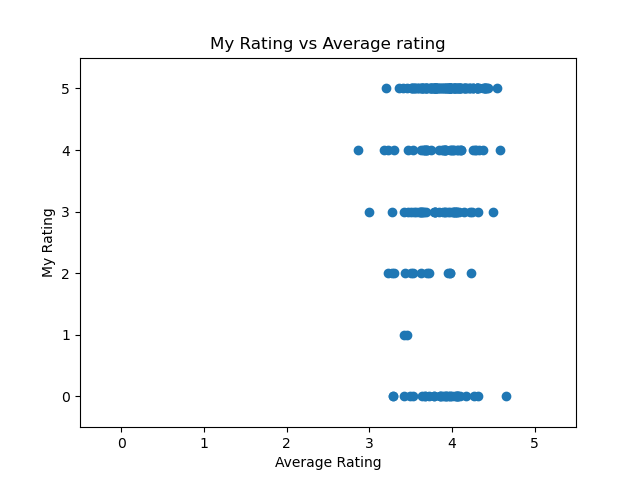

In [55]:

plt.scatter(rating, my_rating)
plt.title('My Rating vs Average rating')
plt.axis((-0.5,5.5,-0.5,5.5))
plt.xlabel('Average Rating')
plt.ylabel('My Rating')
plt.show()

### Example - Titanic Dataset

In [56]:
titanic = pd.read_csv('titanic.csv')

In [57]:
titanic.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [58]:
# Another way of writing df['Age']
titanic.Age

0      22.0
1      38.0
2      26.0
3      35.0
4      35.0
       ... 
886    27.0
887    19.0
888     NaN
889    26.0
890    32.0
Name: Age, Length: 891, dtype: float64

In [59]:
# Let's make some age bins
bins = [0, 18, 35, 60, 100]
labels = ['<18', '18-35', '36-60', '60+']
titanic['age_group'] = pd.cut(titanic['Age'], bins=bins, labels=labels)

In [60]:
age_counts = titanic['age_group'].value_counts()

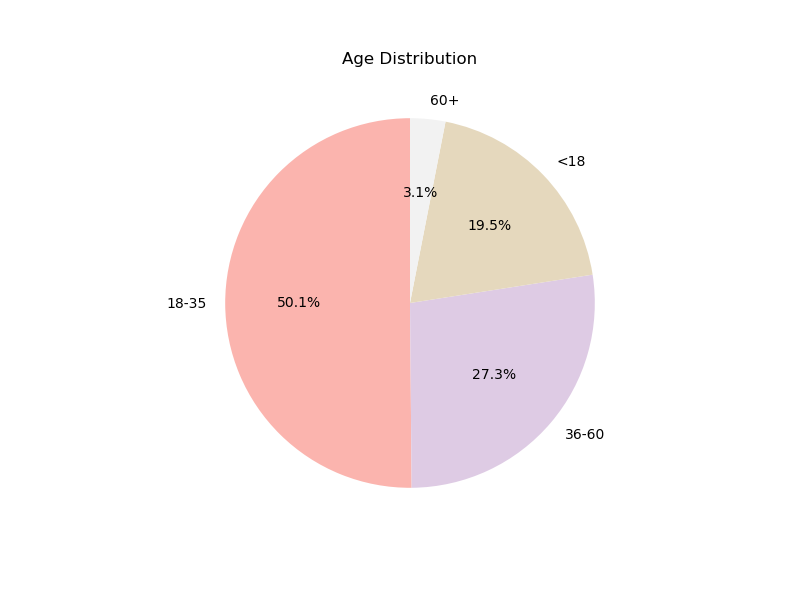

In [61]:
plt.figure(figsize=(8, 6))
age_counts.plot.pie(autopct='%1.1f%%', startangle=90, cmap='Pastel1')
plt.title('Age Distribution')
plt.ylabel('')
plt.show()

In [62]:
titanic[titanic.Survived == 1].describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,342.000000,342.0,342.000000,290.000000,342.000000,342.000000,342.000000
mean,444.368421,1.0,1.950292,28.343690,0.473684,0.464912,48.395408
std,252.358840,0.0,0.863321,14.950952,0.708688,0.771712,66.596998
min,2.000000,1.0,1.000000,0.420000,0.000000,0.000000,0.000000
25%,250.750000,1.0,1.000000,19.000000,0.000000,0.000000,12.475000
50%,439.500000,1.0,2.000000,28.000000,0.000000,0.000000,26.000000
75%,651.500000,1.0,3.000000,36.000000,1.000000,1.000000,57.000000
max,890.000000,1.0,3.000000,80.000000,4.000000,5.000000,512.329200
